# Fare Explainer Notebook
This notebook demonstrates data loading, feature engineering, training an XGBoost GBM, SHAP explainability, residual analysis, and a small query function to evaluate if a specific flight is inflated.

In [1]:
import sys
!{sys.executable} -m pip install xgboost shap scikit-learn pandas

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
   ---------------------------------------- 0.0/549.3 kB ? eta -:--:--
   ---------------------------------------- 549.3/549.3 kB 9.3 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 31.9 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   -------------------------- ------------- 24.9/38.1 MB 121.4 MB/s eta 0:00:01
   ---------------------------------------- 38.1/38.1 MB 89.8 MB/s  0:00:00
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)

   ------ --------------------------------- 1/6 [llvmlite]
   ------ --------------------------------- 1/6 [llvml


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# 1. Imports and helpers
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
import xgboost as xgb
import shap

# Ensure local utils are importable
sys.path.append(str(Path('..').resolve()))
from src.utils import feature_engineer, compute_shap, detect_inflation, suggest_alternatives, rank_corridors

sns.set_theme(style='whitegrid')

c:\Users\micha\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# 2. Load data and run feature engineering
data_path = Path('..') / 'data' / 'airline_ticket_dataset_csv.csv'
df = feature_engineer(pd.read_csv(data_path, dtype=str))

## Feature selection and temporal encoding
We create `fare_per_mile` as a derived unit, a `competitive_pressure` index, and `market_concentration`. We also one-hot `Year` & `quarter` to capture seasonality.

In [4]:
# 3. Setup features and target
candidates = ['nkm', 'passengers_clean', 'orig_total', 'dest_total', 'hub_ratio', 
              'origin_is_hub', 'hub_intensity_orig', 'hub_intensity_dest', 
              'market_concentration', 'competitive_pressure', 'carrier_lg_freq', 'carrier_low_freq']

# Add one-hot encoded years/quarters
df = pd.get_dummies(df, columns=[c for c in ['Year','quarter'] if c in df.columns], drop_first=True)
features = [c for c in candidates if c in df.columns] + [c for c in df.columns if c.startswith(('Year_', 'quarter_'))]

# Ensure target exists and is clean
df = df.dropna(subset=['fare_per_mile'])
X = df[features]
y = df['fare_per_mile']

In [5]:
# 4. Prepare target and split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3169)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=3169)

imputer = SimpleImputer(strategy='median')
X_tr = pd.DataFrame(imputer.fit_transform(X_tr), columns=features)
X_val = pd.DataFrame(imputer.transform(X_val), columns=features)
X_test = pd.DataFrame(imputer.transform(X_test), columns=features)

## Train GBM (XGBoost)
We train a GBM to predict `fare_per_mile`. Predicted fare = predicted_per_mile * distance.

In [6]:
# 5. Train model
model = xgb.XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.05, 
    tree_method='hist', 
    random_state=3169,
    early_stopping_rounds=50,
    eval_metric='mae'
)
model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=True)

[0]	validation_0-mae:0.11750
[1]	validation_0-mae:0.11216
[2]	validation_0-mae:0.10707
[3]	validation_0-mae:0.10223
[4]	validation_0-mae:0.09766
[5]	validation_0-mae:0.09336
[6]	validation_0-mae:0.08931
[7]	validation_0-mae:0.08551
[8]	validation_0-mae:0.08190
[9]	validation_0-mae:0.07848
[10]	validation_0-mae:0.07528
[11]	validation_0-mae:0.07226
[12]	validation_0-mae:0.06938
[13]	validation_0-mae:0.06671
[14]	validation_0-mae:0.06417
[15]	validation_0-mae:0.06175
[16]	validation_0-mae:0.05951
[17]	validation_0-mae:0.05739
[18]	validation_0-mae:0.05540
[19]	validation_0-mae:0.05351
[20]	validation_0-mae:0.05172
[21]	validation_0-mae:0.05008
[22]	validation_0-mae:0.04853
[23]	validation_0-mae:0.04709
[24]	validation_0-mae:0.04574
[25]	validation_0-mae:0.04449
[26]	validation_0-mae:0.04331
[27]	validation_0-mae:0.04220
[28]	validation_0-mae:0.04120
[29]	validation_0-mae:0.04023
[30]	validation_0-mae:0.03934
[31]	validation_0-mae:0.03854
[32]	validation_0-mae:0.03774
[33]	validation_0-ma

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric='mae', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

## SHAP explainability
Compute SHAP values to show feature importance and per-row explanations.

In [7]:
# 6. SHAP Analysis
compute_shap(model, X_test, 'shap_summary.png')

## Residual analysis (overpriced vs. high-value corridors)
Residual = Actual - Predicted. Positive residuals indicate overpriced routes.

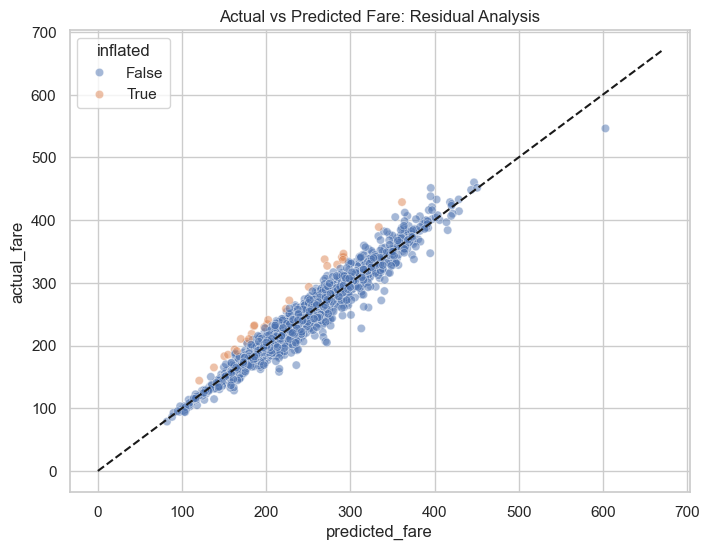

In [8]:
# 6. Residual Analysis and Market Diagnostics
# Impute full dataset for inference
X_full = pd.DataFrame(imputer.transform(df[features]), columns=features)
df_preds = detect_inflation(df, features, model, X_full)

# Plotting residuals
plt.figure(figsize=(8,6))
sns.scatterplot(x='predicted_fare', y='actual_fare', hue='inflated', data=df_preds.sample(min(2000, len(df_preds))), alpha=0.5)
plt.plot([0, df_preds['predicted_fare'].max()], [0, df_preds['predicted_fare'].max()], color='k', linestyle='--')
plt.title('Actual vs Predicted Fare: Residual Analysis')
plt.show()

In [15]:
# 7. Generate Insights for Presentation
inflated_flights = suggest_alternatives(df_preds, features)
corridor_rankings = rank_corridors(df_preds)

out_dir = Path('report')
out_dir.mkdir(parents=True, exist_ok=True)

inflated_flights.to_csv(out_dir / 'full_inflated_routes_report.csv', index=False)
print("Full report saved to notebooks/full_inflated_routes_report.csv")

print("Top inflated routes detected:\n", inflated_flights.head(7).to_string(index=False))

Full report saved to notebooks/full_inflated_routes_report.csv
Top inflated routes detected:
                           city1                                 city2  actual_fare  predicted_fare  pct_diff                                                                                            suggested_alternatives
                     Albany, NY                            Denver, CO       316.06      253.710499  0.245751                         Miami, FL (Metropolitan Area);Miami, FL (Metropolitan Area);Tampa, FL (Metropolitan Area)
                   Amarillo, TX                 Dallas/Fort Worth, TX       195.29      165.991023  0.176509                                                                                                                  
                  Asheville, NC         Miami, FL (Metropolitan Area)       165.04      137.917030  0.196662                                                                                Denver, CO;Sanford, FL;Sanford, FL
              

## Simple query: evaluate a city-pair and suggest alternatives

In [16]:
def query_route(origin, dest, df_preds, model, features, top_k=3):
    # This acts as the wrapper for the logic now stored in utils
    candidate = df_preds[(df_preds['city1'] == origin) & (df_preds['city2'] == dest)]
    if candidate.empty:
        return f"No data found for {origin} -> {dest}"
    
    row = candidate.iloc[0]
    
    # Generate alternatives using the utility function
    # Note: We pass the full df_preds to filter against the whole market
    all_alts = suggest_alternatives(df_preds, features, top_k=top_k)
    
    # Filter for this specific route's alternatives
    my_alts = all_alts[all_alts['city1'] == origin]
    
    return {
        "Route": f"{origin} -> {dest}",
        "Actual Fare": f"${row['actual_fare']:.2f}",
        "Model Prediction": f"${row['predicted_fare']:.2f}",
        "Value Rating": "Overpriced" if row['inflated'] else "Fair/High Value",
        "Top Alternatives": my_alts['suggested_alternatives'].iloc[0] if not my_alts.empty else "None"
    }

In [ ]:
print(query_route("Atlanta, GA (Metropolitan Area)", "Los Angeles, CA (Metropolitan Area)", df_preds, model, features))

No data found for ATL -> LAX
